In [20]:
import pandas as pd
from sqlalchemy import create_engine, inspect
import psycopg2
import json

# Define PostgreSQL connection details
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'Analytics'
DB_USER = 'postgres'
DB_PASSWORD = 'admin'

# Create a connection engine
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

# Function to read data back from PostgreSQL
def read_from_postgres(table_name):
    try:
        query = f"SELECT * FROM {table_name};"
        with engine.connect() as connection:
            df = pd.read_sql(query, connection)
        print(f"Data retrieved from {table_name} successfully.")
        return df
    except Exception as e:
        print(f"Error reading from {table_name}: {e}")
        return None

# Retrieve data back into Pandas DataFrames
df_web_scraped_retrieved = read_from_postgres('web_scraped_data')
df_washington_vehicle_retrieved = read_from_postgres('washington_vehicle_population')
df_fuel_station_ev_retrieved = read_from_postgres('fuel_station_ev')
df_fuel_station_all_retrieved = read_from_postgres('fuel_station_all')

# Verify the data
print("Web Scraped Data: ", df_web_scraped_retrieved.head())
print("Washington Vehicle Data: ", df_washington_vehicle_retrieved.head())
print("Fuel Station EV Data: ", df_fuel_station_ev_retrieved.head())
print("Fuel Station All Data: ", df_fuel_station_all_retrieved.head())

Data retrieved from web_scraped_data successfully.
Data retrieved from washington_vehicle_population successfully.
Data retrieved from fuel_station_ev successfully.
Data retrieved from fuel_station_all successfully.
Web Scraped Data:     IsRecentlyVerified      DateLastVerified      ID  \
0                True  2024-12-09T19:51:00Z  306889   
1                True  2024-12-09T19:34:00Z  306887   
2                True  2024-12-09T19:27:00Z  306886   
3                True  2024-12-10T06:04:00Z  306811   
4                True  2024-12-09T20:29:00Z  306807   

                                   UUID  DataProviderID  \
0  BDA8E854-2B5A-4CBC-B836-81669C53B6FF               1   
1  48580F8F-D1AC-4EEE-9F68-89036147C2D0               1   
2  3D345F5E-33FC-43A2-9649-A02685B88147               1   
3  999827CB-EA74-459E-92CB-88AF60DA1D8F               1   
4  E85F880B-8EE3-4F7B-9E91-44D161C8BC62               1   

  DataProvidersReference  OperatorID  UsageTypeID  \
0                   None  

In [21]:
# Verify the data
print("Web Scraped Data: ", df_web_scraped_retrieved.shape)
print("Washington Vehicle Data: ", df_washington_vehicle_retrieved.shape)
print("Fuel Station EV Data: ", df_fuel_station_ev_retrieved.shape)
print("Fuel Station All Data: ", df_fuel_station_all_retrieved.shape)

Web Scraped Data:  (50000, 61)
Washington Vehicle Data:  (216772, 17)
Fuel Station EV Data:  (228716, 39)
Fuel Station All Data:  (139112, 33)


In [22]:
# Verify the data
print("Web Scraped Data: ", df_web_scraped_retrieved.isna().sum().to_dict())
print()
print("Washington Vehicle Data: ", df_washington_vehicle_retrieved.isna().sum().to_dict())
print()
print("Fuel Station EV Data: ", df_fuel_station_ev_retrieved.isna().sum().to_dict())
print()
print("Fuel Station All Data: ", df_fuel_station_all_retrieved.isna().sum().to_dict())

Web Scraped Data:  {'IsRecentlyVerified': 0, 'DateLastVerified': 0, 'ID': 0, 'UUID': 0, 'DataProviderID': 0, 'DataProvidersReference': 7283, 'OperatorID': 6910, 'UsageTypeID': 5, 'Connections': 0, 'StatusTypeID': 3406, 'DateLastStatusUpdate': 0, 'DataQualityLevel': 0, 'DateCreated': 0, 'SubmissionStatusTypeID': 0, 'DataProvider.WebsiteURL': 0, 'DataProvider.DataProviderStatusType.IsProviderEnabled': 0, 'DataProvider.DataProviderStatusType.ID': 0, 'DataProvider.DataProviderStatusType.Title': 0, 'DataProvider.IsRestrictedEdit': 0, 'DataProvider.IsOpenDataLicensed': 0, 'DataProvider.IsApprovedImport': 0, 'DataProvider.License': 0, 'DataProvider.DateLastImported': 7283, 'DataProvider.ID': 0, 'DataProvider.Title': 0, 'OperatorInfo.WebsiteURL': 7462, 'OperatorInfo.Comments': 25257, 'OperatorInfo.PhonePrimaryContact': 19937, 'OperatorInfo.IsPrivateIndividual': 7326, 'OperatorInfo.IsRestrictedEdit': 7470, 'OperatorInfo.ID': 6910, 'OperatorInfo.Title': 6910, 'UsageType.IsPayAtLocation': 44117, 

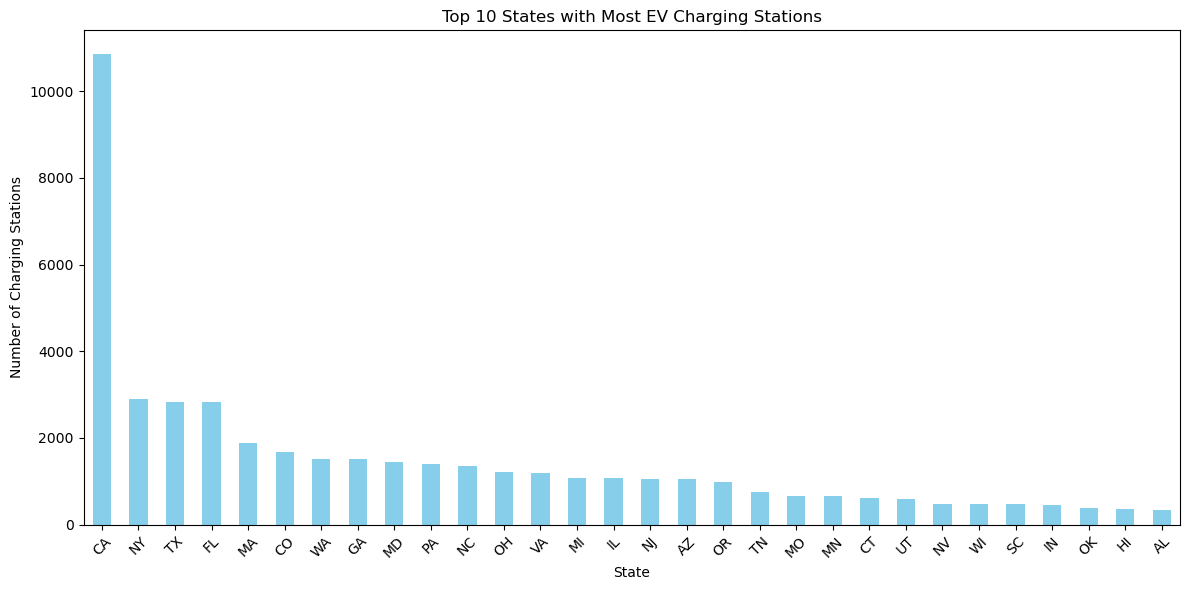

In [23]:
import matplotlib.pyplot as plt

top_states = df_web_scraped_retrieved['AddressInfo.StateOrProvince'].value_counts().head(30)

plt.figure(figsize=(12, 6))
top_states.plot(kind='bar', color='skyblue')
plt.title('Top 10 States with Most EV Charging Stations')
plt.xlabel('State')
plt.ylabel('Number of Charging Stations')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


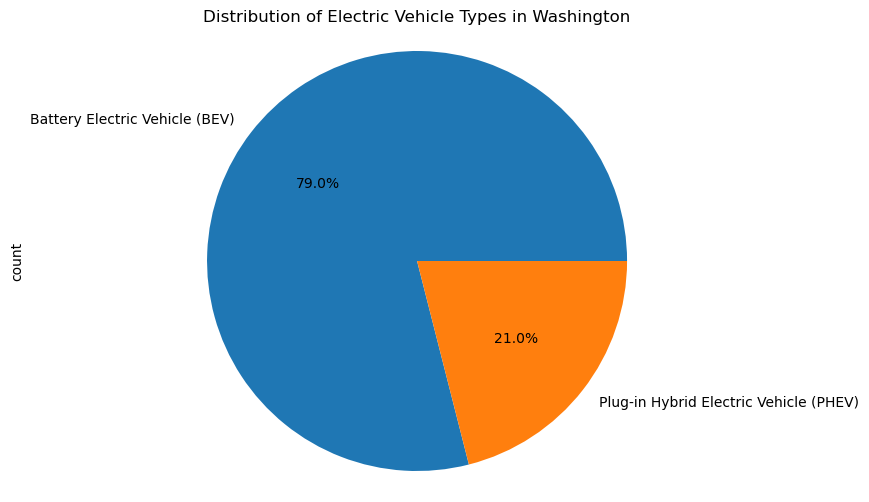

In [24]:
### 2. EV Types in Washington

ev_types = df_washington_vehicle_retrieved['Electric Vehicle Type'].value_counts()

plt.figure(figsize=(10, 6))
ev_types.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Electric Vehicle Types in Washington')
plt.axis('equal')
plt.show()


In [25]:
### 3. Charging Station Map
import folium
from folium.plugins import MarkerCluster
from IPython.display import display, IFrame

# Create a map centered on the US
m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

# Add a marker cluster
marker_cluster = MarkerCluster().add_to(m)

# Add markers to the cluster
for idx, row in df_web_scraped_retrieved.iterrows():
    folium.Marker(
        location=[row['AddressInfo.Latitude'], row['AddressInfo.Longitude']], 
        popup=row['AddressInfo.Title']
    ).add_to(marker_cluster)

# Save the map to an HTML file
map_file = 'charging_stations_map.html'
m.save(map_file)

# Display the map
display(IFrame(map_file, width=700, height=500))


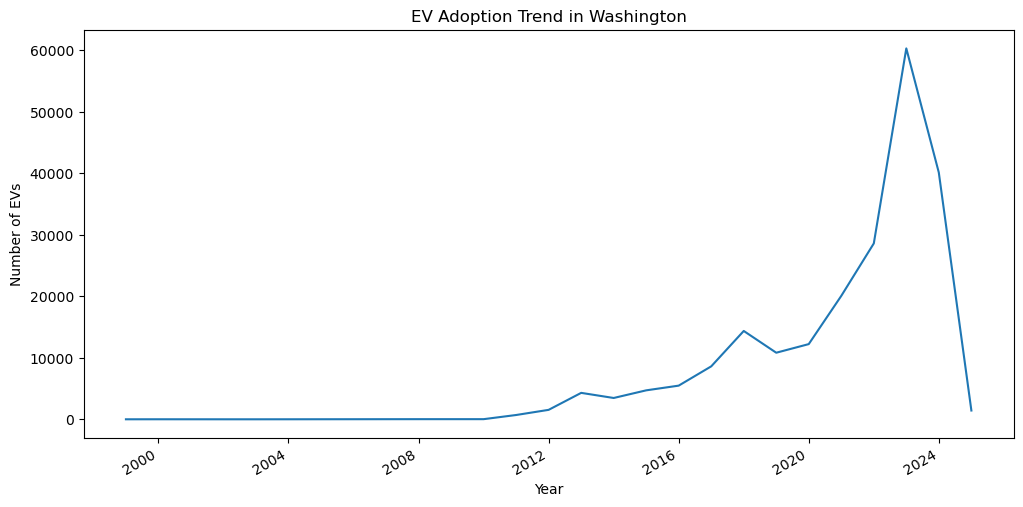

In [26]:
## 5. EV Adoption Trend

df_washington_vehicle_retrieved['Model Year'] = pd.to_datetime(df_washington_vehicle_retrieved['Model Year'], format='%Y')
yearly_adoption = df_washington_vehicle_retrieved.groupby('Model Year').size()

plt.figure(figsize=(12, 6))
yearly_adoption.plot(kind='line')
plt.title('EV Adoption Trend in Washington')
plt.xlabel('Year')
plt.ylabel('Number of EVs')
plt.show() 

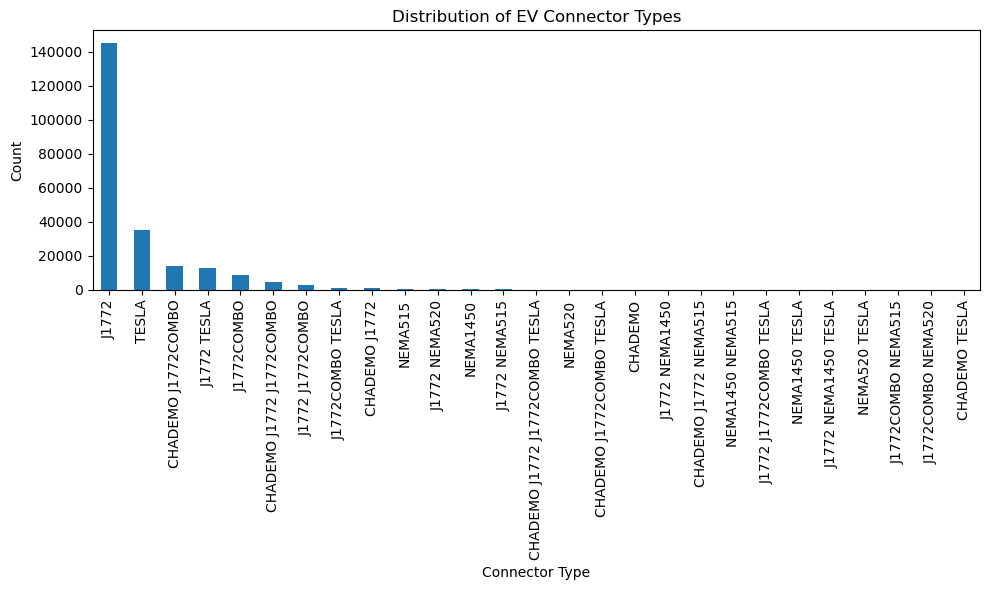

In [27]:
### 6. Charging Station Types

connector_types = df_fuel_station_ev_retrieved['EV Connector Types'].str.get_dummies(sep=',')
connector_counts = connector_types.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
connector_counts.plot(kind='bar')
plt.title('Distribution of EV Connector Types')
print()
plt.xlabel('Connector Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

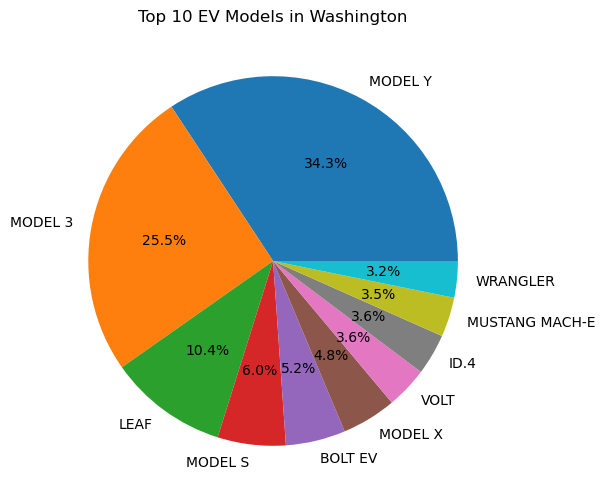

In [28]:
### 2. EV Models in Washington

# Top 10 EV models
top_models = df_washington_vehicle_retrieved['Model'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_models.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 EV Models in Washington')
plt.ylabel('')
plt.show()

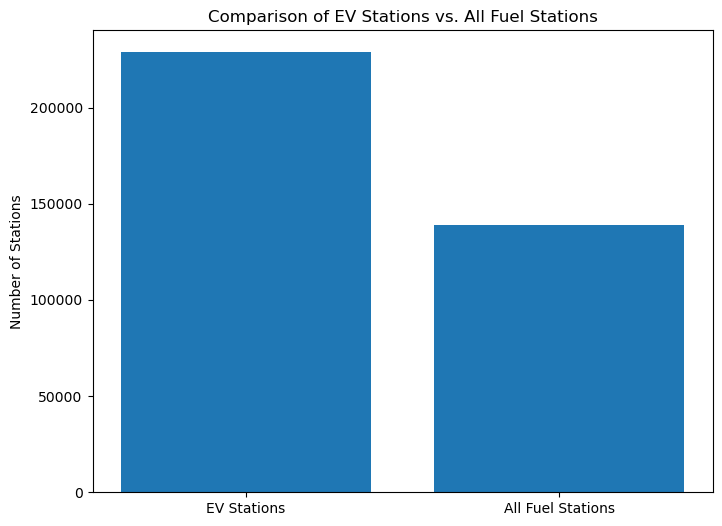

In [29]:
### 8. Comparative Analysis: EV vs. All Fuel Stations

# Count of EV stations vs. all fuel stations
ev_count = len(df_fuel_station_ev_retrieved)
all_count = len(df_fuel_station_all_retrieved)

plt.figure(figsize=(8, 6))
plt.bar(['EV Stations', 'All Fuel Stations'], [ev_count, all_count])
plt.title('Comparison of EV Stations vs. All Fuel Stations')
plt.ylabel('Number of Stations')
plt.show()

In [30]:
# Create a new dataframe with 1000 values from each existing dataframe
merged_data = pd.concat([
    df_web_scraped_retrieved.head(1000),
    df_washington_vehicle_retrieved.head(1000),
    df_fuel_station_ev_retrieved.head(1000),
    df_fuel_station_all_retrieved.head(1000)
], axis=0, ignore_index=True)

print("\nCombined Dataframe Shape:", merged_data.shape)
print("Combined Dataframe Columns:", merged_data.isna().sum().to_dict())


Combined Dataframe Shape: (4000, 114)
Combined Dataframe Columns: {'IsRecentlyVerified': 3000, 'DateLastVerified': 3000, 'ID': 1000, 'UUID': 3000, 'DataProviderID': 3000, 'DataProvidersReference': 3468, 'OperatorID': 3093, 'UsageTypeID': 3002, 'Connections': 3000, 'StatusTypeID': 3000, 'DateLastStatusUpdate': 3000, 'DataQualityLevel': 3000, 'DateCreated': 3000, 'SubmissionStatusTypeID': 3000, 'DataProvider.WebsiteURL': 3000, 'DataProvider.DataProviderStatusType.IsProviderEnabled': 3000, 'DataProvider.DataProviderStatusType.ID': 3000, 'DataProvider.DataProviderStatusType.Title': 3000, 'DataProvider.IsRestrictedEdit': 3000, 'DataProvider.IsOpenDataLicensed': 3000, 'DataProvider.IsApprovedImport': 3000, 'DataProvider.License': 3000, 'DataProvider.DateLastImported': 3468, 'DataProvider.ID': 3000, 'DataProvider.Title': 3000, 'OperatorInfo.WebsiteURL': 3148, 'OperatorInfo.Comments': 3510, 'OperatorInfo.PhonePrimaryContact': 3551, 'OperatorInfo.IsPrivateIndividual': 3138, 'OperatorInfo.IsRes

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

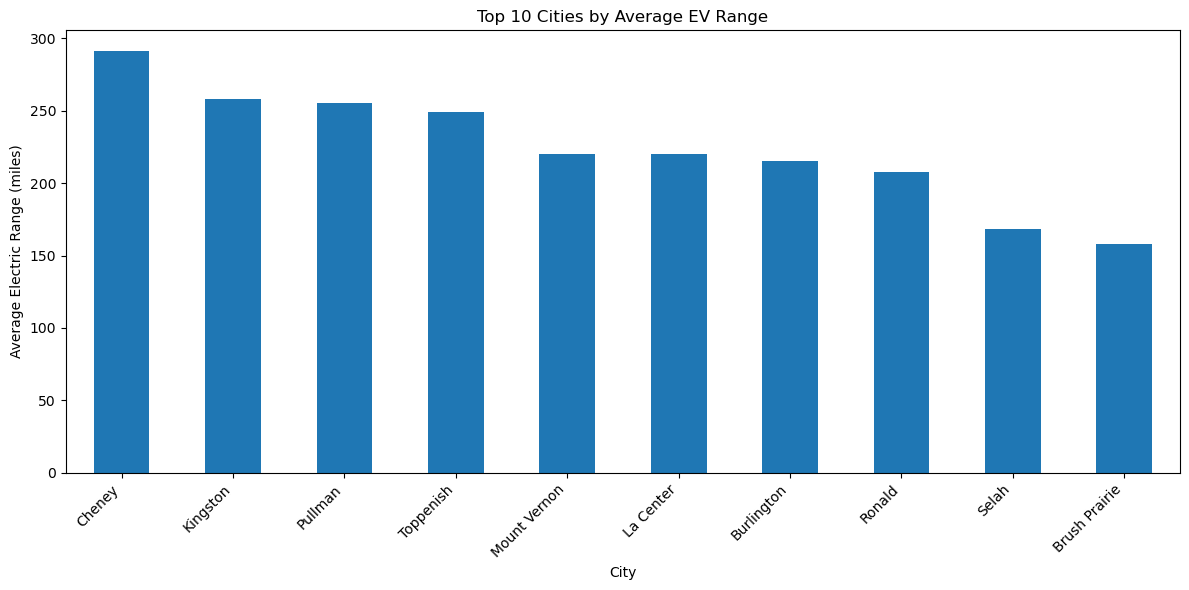

In [32]:

# 7. Average electric range by city
avg_range_by_city = merged_data.groupby('City')['Electric Range'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
avg_range_by_city.plot(kind='bar')
plt.title('Top 10 Cities by Average EV Range')
plt.xlabel('City')
plt.ylabel('Average Electric Range (miles)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

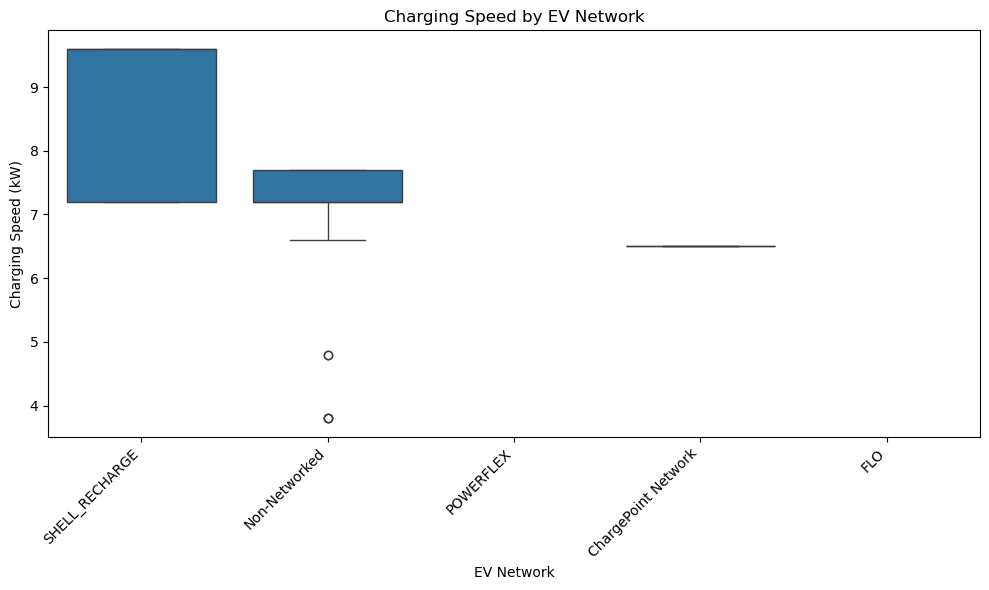

In [33]:
# 5. Charging Speed Analysis
merged_data['Charging_Speed'] = pd.to_numeric(merged_data['EV J1772 Power Output (kW)'], errors='coerce')
plt.figure(figsize=(10, 6))
sns.boxplot(x='EV Network', y='Charging_Speed', data=merged_data)
plt.title('Charging Speed by EV Network')
plt.xlabel('EV Network')
plt.ylabel('Charging Speed (kW)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

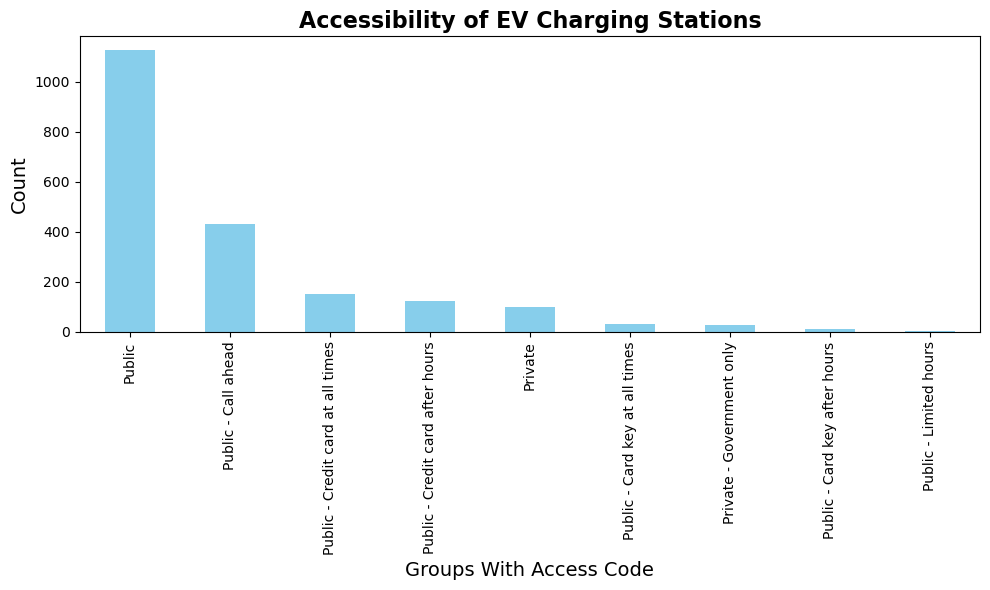

In [34]:
import matplotlib.pyplot as plt

# Count the occurrences of different groups with access codes
accessibility = merged_data['Groups With Access Code'].value_counts()

# Create a bar plot
plt.figure(figsize=(10, 6))
accessibility.plot(kind='bar', color='skyblue')

# Add title and labels
plt.title('Accessibility of EV Charging Stations', fontsize=16, weight='bold')
plt.xlabel('Groups With Access Code', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Display the plot
plt.tight_layout()
plt.show()

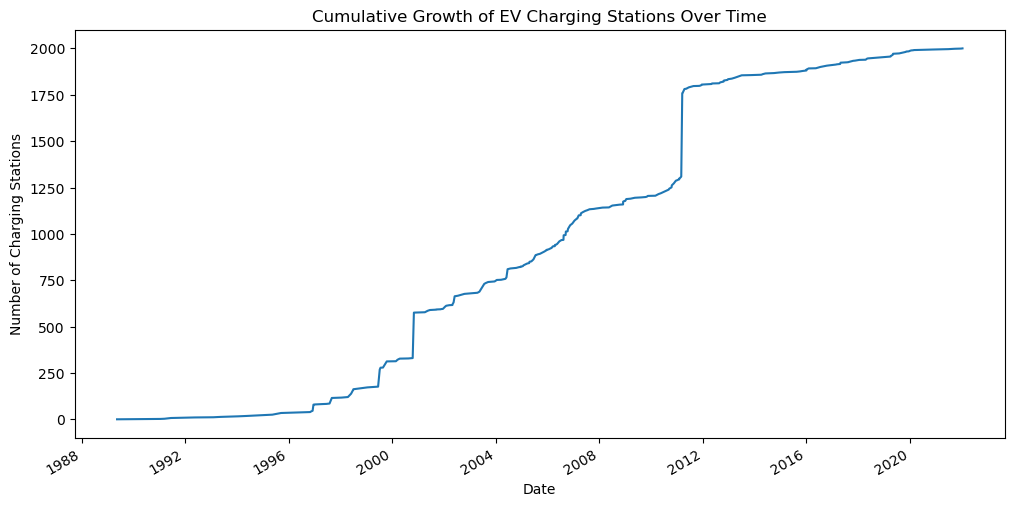

In [35]:
# 9. Time Series Analysis of Charging Station Growth
merged_data['Open Date'] = pd.to_datetime(merged_data['Open Date'], errors='coerce')
station_growth = merged_data.groupby('Open Date').size().cumsum()

plt.figure(figsize=(12, 6))
station_growth.plot()
plt.title('Cumulative Growth of EV Charging Stations Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Charging Stations')
plt.show()

17:32:56 - cmdstanpy - INFO - Chain [1] start processing
17:33:00 - cmdstanpy - INFO - Chain [1] done processing


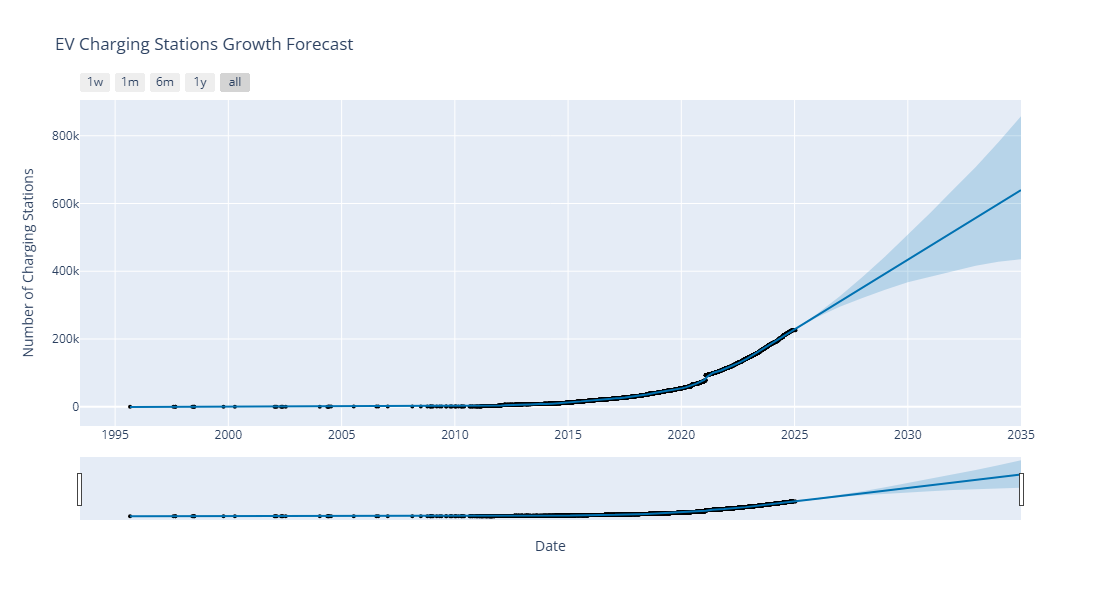


EV Charging Stations Growth Forecast:
             ds           yhat     yhat_lower     yhat_upper
3944 2025-12-31  268868.061943  264031.800046  274270.327909
3945 2026-12-31  310019.426370  295173.334032  326244.070637
3946 2027-12-31  351170.716444  321077.095603  382999.355106
3947 2028-12-31  392397.225899  345650.965919  443583.803010
3948 2029-12-31  433548.655608  367182.384746  508281.448527
3949 2030-12-31  474700.020036  383796.345707  572646.667849
3950 2031-12-31  515851.310110  401705.413470  640748.449525
3951 2032-12-31  557077.819565  416381.533113  708105.236858
3952 2033-12-31  598229.249274  427691.423020  781080.245555
3953 2034-12-31  639380.613701  435416.559540  857490.264392


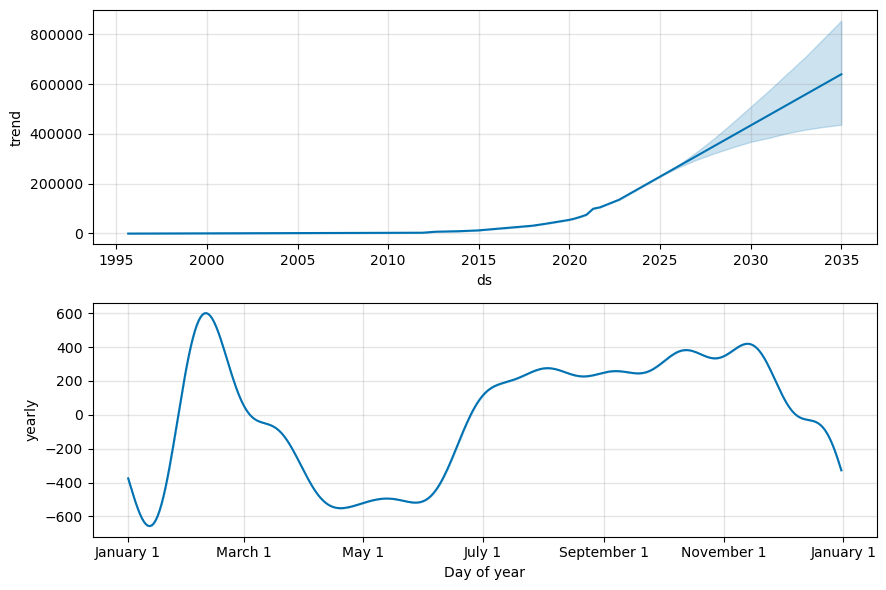


Projected 10-year Compound Annual Growth Rate: 10.81%


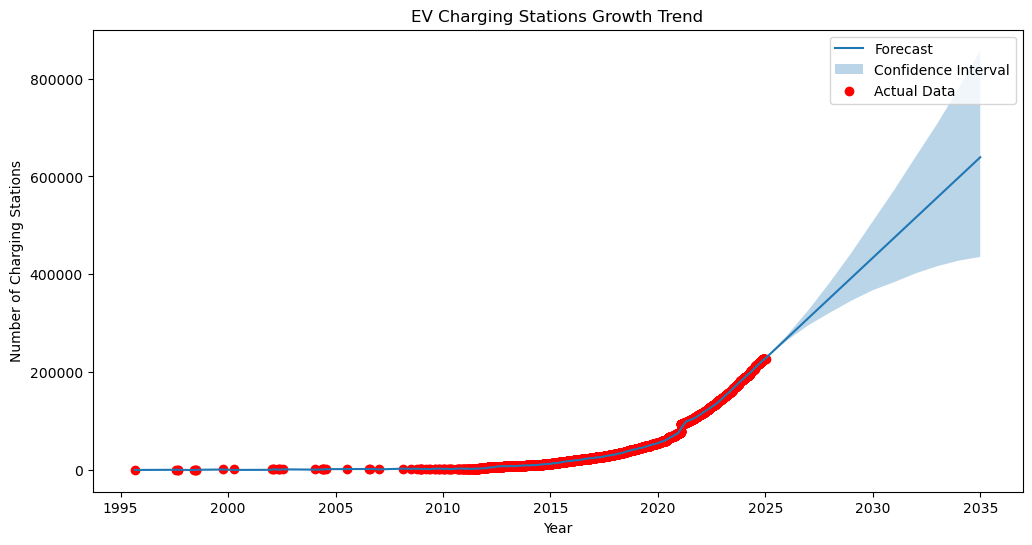

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.plot import plot_plotly, add_changepoints_to_plot

# Assuming df_fuel_station_ev_retrieved is already loaded

# Prepare data for EV charging stations growth
df_fuel_station_ev_retrieved['Open Date'] = pd.to_datetime(df_fuel_station_ev_retrieved['Open Date'])
stations_growth = df_fuel_station_ev_retrieved.groupby('Open Date').size().cumsum().reset_index()
stations_growth.columns = ['ds', 'y']

# Function to forecast growth
def forecast_charging_stations(data, periods=5):
    # Fit Prophet model
    model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
    model.fit(data)

    # Create future dataframe for forecasting
    future = model.make_future_dataframe(periods=periods, freq='YE')
    
    # Make predictions
    forecast = model.predict(future)

    # Plot the forecast
    fig = plot_plotly(model, forecast)
    fig.update_layout(title='EV Charging Stations Growth Forecast', xaxis_title='Date', yaxis_title='Number of Charging Stations')
    fig.show()

    # Print forecast values
    print("\nEV Charging Stations Growth Forecast:")
    print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(periods))

    # Plot components
    model.plot_components(forecast)
    plt.show()

    return forecast

# Forecast EV charging stations growth
stations_forecast = forecast_charging_stations(stations_growth, periods=10)

# Calculate growth rate
current_stations = stations_forecast['yhat'].iloc[-11]  # Current year
future_stations = stations_forecast['yhat'].iloc[-1]   # 10 years in the future
growth_rate = (future_stations / current_stations) ** (1/10) - 1  # Compound Annual Growth Rate

print(f"\nProjected 10-year Compound Annual Growth Rate: {growth_rate:.2%}")

# Visualize the trend
plt.figure(figsize=(12, 6))
plt.plot(stations_forecast['ds'], stations_forecast['yhat'], label='Forecast')
plt.fill_between(stations_forecast['ds'], stations_forecast['yhat_lower'], stations_forecast['yhat_upper'], alpha=0.3, label='Confidence Interval')
plt.scatter(stations_growth['ds'], stations_growth['y'], color='red', label='Actual Data')
plt.title('EV Charging Stations Growth Trend')
plt.xlabel('Year')
plt.ylabel('Number of Charging Stations')
plt.legend()
plt.show()


In [42]:
from dash import Dash, html, dcc
from dash.dependencies import Input, Output
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import folium
from folium.plugins import MarkerCluster

# Initialize Dash app
app = Dash(__name__)

# Load the data (assuming dataframes are preloaded)
df_web_scraped = df_web_scraped_retrieved
df_washington_vehicle = df_washington_vehicle_retrieved
df_fuel_station_ev = df_fuel_station_ev_retrieved
df_fuel_station_all = df_fuel_station_all_retrieved

# Visualization Functions
def create_top_states_chart():
    top_states = df_web_scraped['AddressInfo.StateOrProvince'].value_counts().head(30)
    fig = px.bar(top_states, x=top_states.index, y=top_states.values, 
                 labels={'x': 'State', 'y': 'Number of Charging Stations'},
                 title='Top States with Most EV Charging Stations')
    return fig

def create_ev_types_chart():
    ev_types = df_washington_vehicle['Electric Vehicle Type'].value_counts()
    fig = px.pie(values=ev_types.values, names=ev_types.index, 
                 title='Distribution of Electric Vehicle Types in Washington')
    return fig

def create_ev_models_chart():
    top_models = df_washington_vehicle['Model'].value_counts().head(10)
    fig = px.pie(values=top_models.values, names=top_models.index, 
                 title='Top EV Models in Washington')
    return fig

def create_connector_types_chart():
    connector_types = df_fuel_station_ev['EV Connector Types'].str.get_dummies(sep=',')
    connector_counts = connector_types.sum().sort_values(ascending=False)
    fig = px.bar(connector_counts, x=connector_counts.index, y=connector_counts.values, 
                 labels={'x': 'Connector Type', 'y': 'Count'},
                 title='Distribution of EV Connector Types')
    return fig

def create_station_growth_chart():
    df_fuel_station_ev['Open Date'] = pd.to_datetime(df_fuel_station_ev['Open Date'], errors='coerce')
    station_growth = df_fuel_station_ev.groupby('Open Date').size().cumsum()
    fig = px.line(station_growth, labels={'index': 'Date', 'value': 'Number of Stations'},
                  title='Cumulative Growth of EV Charging Stations')
    return fig

# Folium Map Integration
def create_folium_map():
    m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)
    marker_cluster = MarkerCluster().add_to(m)
    for idx, row in df_web_scraped.iterrows():
        folium.Marker(
            location=[row['AddressInfo.Latitude'], row['AddressInfo.Longitude']], 
            popup=row['AddressInfo.Title']
        ).add_to(marker_cluster)
    return m._repr_html_()

# Layout
app.layout = html.Div([
    html.H1("EV Data Dashboard", style={'textAlign': 'center'}),
    
    # Dropdown for selecting a visualization
    html.Div([
        dcc.Dropdown(
            id='chart-selector',
            options=[
                {'label': 'Top States with Charging Stations', 'value': 'states'},
                {'label': 'EV Types Distribution', 'value': 'ev_types'},
                {'label': 'Top EV Models in Washington', 'value': 'ev_models'},
                {'label': 'Connector Types Distribution', 'value': 'connector_types'},
                {'label': 'Cumulative Growth of Charging Stations', 'value': 'station_growth'},
                {'label': 'Charging Stations Map', 'value': 'map'}
            ],
            value='states',
            placeholder="Select a Visualization",
            style={'width': '50%'}
        )
    ], style={'textAlign': 'center', 'marginBottom': '20px'}),
    
    # Graph container
    html.Div(id='chart-container', children=[], style={'marginTop': '20px'}),
])

# Callbacks for interactivity
@app.callback(
    Output('chart-container', 'children'),
    [Input('chart-selector', 'value')]
)
def update_chart(chart_type):
    if chart_type == 'states':
        fig = create_top_states_chart()
        return dcc.Graph(figure=fig)
    elif chart_type == 'ev_types':
        fig = create_ev_types_chart()
        return dcc.Graph(figure=fig)
    elif chart_type == 'ev_models':
        fig = create_ev_models_chart()
        return dcc.Graph(figure=fig)
    elif chart_type == 'connector_types':
        fig = create_connector_types_chart()
        return dcc.Graph(figure=fig)
    elif chart_type == 'station_growth':
        fig = create_station_growth_chart()
        return dcc.Graph(figure=fig)
    elif chart_type == 'map':
        map_html = create_folium_map()
        return html.Div([
            html.Iframe(srcDoc=map_html, width='100%', height='600px', style={'border': 'none'})
        ])
    return html.Div("Select a visualization from the dropdown.")

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True, port=8051)
